# S0-4 · Referans bulguların doğrulanması

## tl;dr

Sabitlenmiş `3RAIN/brand-bias-evaluations` verisiyle iki bulgu tam olarak yeniden
üretildi. NordVPN'in VPN öneri payı arama açıkken **+28,17 yüzde puan** değişirken,
VS Code'un editör öneri payı **−0,42 yüzde puan** değişti. Beş hedef sayım ve payda
kaynak değerlerle birebir eşleştiği için değerlendirme **Ready to share**.

## Context & Methods

- Veri: `3RAIN/brand-bias-evaluations`, config `all`, split `train`.
- Revision: `400da04eced51d3afe52b6d20c0207fd613f8a4a` (değişmez).
- Analiz birimi tek model yanıtıdır. Payda, ilgili kategori ve koşuldaki **tüm
  yanıtlardır**; `top_recommendation` null olsa bile satır paydada kalır.
- Alias'lar veri hazırlama sırasında uygulanır: `Mullvad VPN → Mullvad`,
  `Visual Studio Code → VS Code`, `ProtonVPN → Proton VPN`.
- Değişim, `search_on − search_off` olarak yüzde puan cinsinden hesaplanır.

### Key Assumptions

Kaynak etiketleri ve LLM-judge çıkarımları doğru kabul edilir. Düşük confidence
satırları yeniden üretimden çıkarılmaz. Bulgular bu sabit veri sürümünü tarif eder;
daha geniş model veya kullanıcı evrenine nedensel genelleme yapılmaz.

In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Repo kökü bulunamadı.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))

validation_module = importlib.import_module("reference_validation")
build_quality_summary = validation_module.build_quality_summary
build_validation_results = validation_module.build_validation_results
validate_expected_findings = validation_module.validate_expected_findings
plt = importlib.import_module("matplotlib.pyplot")

DATA_PATH = PROJECT_ROOT / "data/interim/reference.parquet"
pd.set_option("display.max_rows", 12)
pd.set_option("display.max_columns", 10)

## Data

Bu bölüm yalnızca denetlenebilir kalite özetlerini gösterir; ham model yanıtları
ve büyük tablolar notebook'a gömülmez.

In [2]:
reference = pd.read_parquet(DATA_PATH)
quality_summary, incomplete_cells = build_quality_summary(reference)

expected_categories = {"vpn": 2388, "travel": 2400, "hosting": 2398, "editors": 2400}
expected_conditions = {"search_off": 4800, "search_on": 4786}
assert reference["category"].value_counts().to_dict() == expected_categories
assert reference["condition"].value_counts().to_dict() == expected_conditions
assert len(reference) == 9586
assert reference["record_id"].nunique() == 9586
assert reference["query_id"].nunique() == 40

dimension_counts = pd.concat(
    [
        reference["category"].value_counts().rename("rows"),
        reference["condition"].value_counts().rename("rows"),
    ],
    keys=["category", "condition"],
).rename_axis(["dimension", "value"]).reset_index()

print(quality_summary.to_string(index=False))
print("\nKategori ve koşul sayımları")
print(dimension_counts.to_string(index=False))

                 check  value
                  Rows   9586
               Columns     87
      Unique record_id   9586
   Duplicate record_id      0
       Unique query_id     40
search_aware null rows   4800

Kategori ve koşul sayımları
dimension      value  rows
 category     travel  2400
 category    editors  2400
 category    hosting  2398
 category        vpn  2388
condition search_off  4800
condition  search_on  4786


In [3]:
confidence = (
    reference["core__confidence_in_extraction"]
    .value_counts()
    .reindex(["high", "medium", "low"], fill_value=0)
    .rename("rows")
    .rename_axis("confidence")
    .reset_index()
)
assert confidence.set_index("confidence")["rows"].to_dict() == {
    "high": 9576,
    "medium": 7,
    "low": 3,
}

non_high = reference.loc[
    reference["core__confidence_in_extraction"].ne("high"),
    ["category", "condition", "query_id", "core__confidence_in_extraction"],
]
non_high_by_cell = (
    non_high.value_counts(sort=False)
    .rename("rows")
    .reset_index()
    .sort_values(["category", "condition", "query_id", "core__confidence_in_extraction"])
)
assert len(non_high) == 10
assert set(non_high["category"]) == {"travel"}

print(confidence.to_string(index=False))
print("\nHigh olmayan etiketlerin hücre özeti")
print(non_high_by_cell.to_string(index=False))
print("\nEksik tekrar hücreleri")
print(incomplete_cells.to_string(index=False))
print("\nNot: Satırlar kalite/sensitivity takibi için ayrılır; S0-4 paydalarından silinmez.")

confidence  rows
      high  9576
    medium     7
       low     3

High olmayan etiketlerin hücre özeti
category  condition  query_id core__confidence_in_extraction  rows
  travel search_off travel_08                            low     2
  travel search_off travel_08                         medium     7
  travel  search_on travel_08                            low     1

Eksik tekrar hücreleri
category      model_id condition   query_id  rows
 hosting zai-org/GLM-5 search_on hosting_04    29
 hosting zai-org/GLM-5 search_on hosting_08    29
     vpn zai-org/GLM-5 search_on     vpn_06    20
     vpn zai-org/GLM-5 search_on     vpn_08    28

Not: Satırlar kalite/sensitivity takibi için ayrılır; S0-4 paydalarından silinmez.


## Results

Tablolardaki oranlar `sayım / ilgili koşuldaki tüm yanıtlar` biçimindedir. Kaynak
değerle karşılaştırma kesin sayım ve payda üzerinden yapılır; yuvarlama yalnızca
sunumdadır.

In [4]:
results = build_validation_results(reference)
validation = validate_expected_findings(results)

shown = results.copy()
shown["pay"] = shown["count"].astype(str) + "/" + shown["denominator"].astype(str)
shown["oran"] = shown["rate_percent"].map(lambda value: f"%{value:.2f}")

comparison = pd.DataFrame(
    [
        {
            "bulgu": "VPN · NordVPN",
            "search_off": "%5,25",
            "search_on": "%33,42",
            "değişim (yp)": f"{validation['vpn_nordvpn_delta_pp']:+.2f}",
        },
        {
            "bulgu": "Editör · VS Code",
            "search_off": "%81,25",
            "search_on": "%80,83",
            "değişim (yp)": f"{validation['editors_vscode_delta_pp']:+.2f}",
        },
    ]
)

print(shown[["finding", "brand", "condition", "pay", "oran"]].to_string(index=False))
print("\nKoşul karşılaştırması")
print(comparison.to_string(index=False))
print(f"\nDeğerlendirme: {validation['assessment']}")

        finding   brand  condition      pay   oran
      vpn_shift Mullvad search_off 589/1200 %49.08
      vpn_shift NordVPN search_off  63/1200  %5.25
      vpn_shift NordVPN  search_on 397/1188 %33.42
editors_control VS Code search_off 975/1200 %81.25
editors_control VS Code  search_on 970/1200 %80.83

Koşul karşılaştırması
           bulgu search_off search_on değişim (yp)
   VPN · NordVPN      %5,25    %33,42       +28.17
Editör · VS Code     %81,25    %80,83        -0.42

Değerlendirme: Ready to share


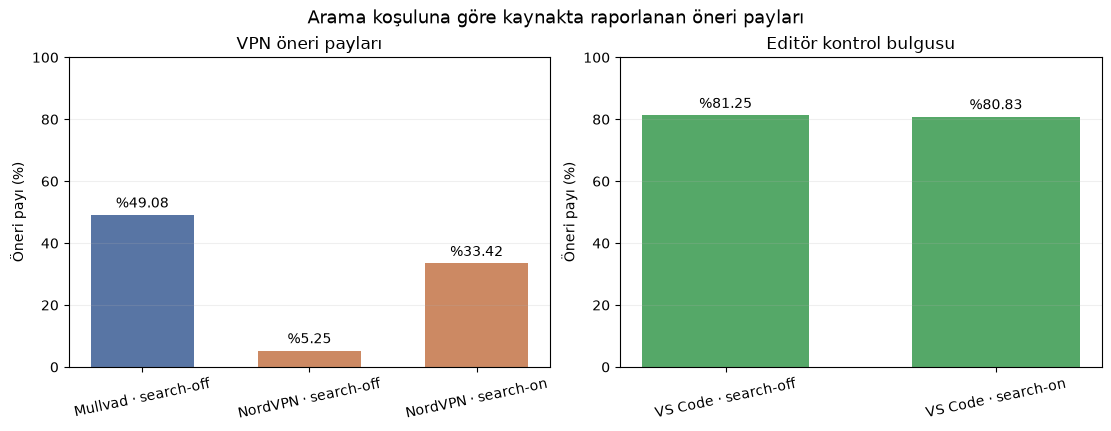

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

vpn_labels = ["Mullvad · search-off", "NordVPN · search-off", "NordVPN · search-on"]
vpn_values = [589 / 1200 * 100, 63 / 1200 * 100, 397 / 1188 * 100]
editor_labels = ["VS Code · search-off", "VS Code · search-on"]
editor_values = [975 / 1200 * 100, 970 / 1200 * 100]

for axis, labels, values, title, colors in [
    (axes[0], vpn_labels, vpn_values, "VPN öneri payları", ["#5875A4", "#CC8963", "#CC8963"]),
    (axes[1], editor_labels, editor_values, "Editör kontrol bulgusu", ["#55A868", "#55A868"]),
]:
    bars = axis.bar(labels, values, color=colors, width=0.62)
    axis.set_ylim(0, 100)
    axis.set_ylabel("Öneri payı (%)")
    axis.set_title(title)
    axis.tick_params(axis="x", labelrotation=12)
    axis.grid(axis="y", alpha=0.2)
    axis.bar_label(bars, labels=[f"%{value:.2f}" for value in values], padding=3)

fig.suptitle("Arama koşuluna göre kaynakta raporlanan öneri payları", fontsize=13)
plt.show()

## Takeaways

- **VPN değişimi doğrulandı:** Mullvad search-off `589/1200 = %49,08`;
  NordVPN `63/1200 = %5,25` düzeyinden search-on `397/1188 = %33,42`
  düzeyine çıktı (**+28,17 yüzde puan**).
- **Editör kontrolü doğrulandı:** VS Code `975/1200 = %81,25` düzeyinden
  `970/1200 = %80,83` düzeyine geldi (**−0,42 yüzde puan**); arama etkisi bu
  kontrol bulgusunda yaklaşık sıfır.
- GLM-5/search-on altında dört deney hücresi 30 yerine 29, 29, 20 ve 28 satırdır.
  Bu nedenle VPN search-on paydası 1.200 değil 1.188'dir.
- Confidence dağılımı `high=9.576`, `medium=7`, `low=3` olup hiçbir satır bu
  yeniden üretimde elenmemiştir.
- Sonuç, sabit veri revision'ı ve tanımlı alias'lar için **Ready to share**;
  etiketleme doğruluğu veya farklı model sürümleri için ayrıca doğrulama gerekir.